In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from scipy.special import gammaln
import math

# === Parameters ===
DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
HORIZON     = 5
RECOVERY    = 0.4

EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Qatar', 'Colombia',
             'Mexico', 'Brazil', 'Egypt', 'Malaysia']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
             'South Korea', 'Thailand', 'Turkey']

# M1/ M2 parameters
GAMMA = 0.15
J = -0.074116

# === Load results ===
PATHS = {
    'M0': '../output/results/final_inchallah/M0_results_5YCDS_weekly.csv',
    'M1': '../output/results/final_inchallah/M1_results_5YCDS_weekly_15_dampening.csv',
    'M2': '../output/results/final_inchallah/M2_results_5YCDS_weekly_15_dampening.csv',
}

dfs = {}
for model, path in PATHS.items():
    dfs[model] = pd.read_csv(path, parse_dates=[DATE_COL])

# === Build panel: M0 is base, merge M1 and M2 ===
# Shared columns come from M0 only
shared = [DATE_COL, COUNTRY_COL, CDS_COL, 'risk_free_rate', 'B_f', 'LCL_usd', 'sigma_lcl']
calibration = ['implied_V', 'implied_sigma_V', 'cca_converged']

panel = dfs['M0'][shared + calibration].rename(
    columns={c: f'{c}_M0' for c in calibration}
)

for model in ['M1', 'M2']:
    model_cols = calibration.copy()
    if model == 'M1':
        model_cols += ['convenience_yield']
    elif model == 'M2':
        model_cols += ['lambda_annual']

    df = dfs[model][[DATE_COL, COUNTRY_COL] + model_cols].rename(
        columns={c: f'{c}_{model}' for c in calibration}
    )
    panel = panel.merge(df, on=[DATE_COL, COUNTRY_COL], how='inner')

panel = panel[panel[COUNTRY_COL].isin(EXPORTERS + CONTROLS)].copy()
panel['group'] = panel[COUNTRY_COL].apply(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
panel['exporter'] = (panel['group'] == 'Exporter').astype(float)

print(f"Panel: {len(panel)} rows, {panel[COUNTRY_COL].nunique()} countries")
print(f"Date range: {panel[DATE_COL].min().date()} to {panel[DATE_COL].max().date()}")
print(f"\nConvergence rates:")
for m in ['M0', 'M1', 'M2']:
    rate = panel[f'cca_converged_{m}'].mean()
    print(f"  {m}: {rate:.1%}")
panel

Panel: 8352 rows, 16 countries
Date range: 2015-01-04 to 2024-12-29

Convergence rates:
  M0: 97.4%
  M1: 100.0%
  M2: 100.0%


,date,country,cds_spread,risk_free_rate,B_f,LCL_usd,sigma_lcl,implied_V_M0,implied_sigma_V_M0,cca_converged_M0,implied_V_M1,implied_sigma_V_M1,cca_converged_M1,convenience_yield,implied_V_M2,implied_sigma_V_M2,cca_converged_M2,lambda_annual,group,exporter
0,2015-01-04,Brazil,207.97000,0.0255,631.896100,160.267363,0.216490,716.278840,0.048877,True,1201.282394,0.092116,True,-0.154664,1343.685062,0.214389,True,41.078490,Exporter,1.0
1,2015-01-11,Brazil,201.92000,0.0255,631.896100,164.166318,0.217782,720.164952,0.050101,True,1193.616967,0.093935,True,-0.182126,1365.166562,0.198943,True,34.922904,Exporter,1.0
2,2015-01-18,Brazil,205.65000,0.0255,631.896100,164.740583,0.217691,720.740037,0.050213,True,1215.514162,0.094024,True,-0.160653,1364.568361,0.225633,True,44.573085,Exporter,1.0
3,2015-01-25,Brazil,193.65000,0.0255,631.896100,167.374429,0.217070,723.379631,0.050669,True,1217.100541,0.093755,True,-0.171523,1377.071863,0.230617,True,46.531785,Exporter,1.0
4,2015-02-01,Brazil,212.77000,0.0220,622.088400,144.931270,0.239328,701.694687,0.050322,True,1207.427935,0.093118,True,-0.159916,1352.775296,0.234887,True,48.232713,Exporter,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8347,2024-12-01,UAE (Abu Dhabi),39.78999,0.0463,600.079655,41.583101,0.081109,517.651912,0.006515,True,703.342576,0.036519,True,0.074805,660.070598,0.104194,True,18.184232,Exporter,1.0
8348,2024-12-08,UAE (Abu Dhabi),40.27000,0.0463,600.079655,41.584628,0.081109,517.653439,0.006516,True,704.653843,0.036520,True,0.077274,661.856400,0.094313,True,15.098801,Exporter,1.0
8349,2024-12-15,UAE (Abu Dhabi),41.14000,0.0463,600.079655,41.584628,0.081107,517.653439,0.006516,True,707.094760,0.036520,True,0.081885,660.094048,0.104115,True,18.159062,Exporter,1.0
8350,2024-12-22,UAE (Abu Dhabi),43.27000,0.0463,600.079655,41.583101,0.081107,517.651912,0.006515,True,704.809810,0.036519,True,0.077583,662.426535,0.090443,True,13.915125,Exporter,1.0


In [40]:
def graphfunc(country, col='implied_V', models=['M0', 'M1', 'M2']):
    colors = {'M0': 'steelblue', 'M1': 'darkorange', 'M2': 'firebrick'}
    df = panel[panel[COUNTRY_COL] == country].sort_values(DATE_COL)
    fig, ax = plt.subplots(figsize=(10, 4))
    for m in models:
        ax.plot(df[DATE_COL], df[f'{col}_{m}'], color=colors[m], lw=0.8, label=m)
    ax.set_title(f'{country} — {col}', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

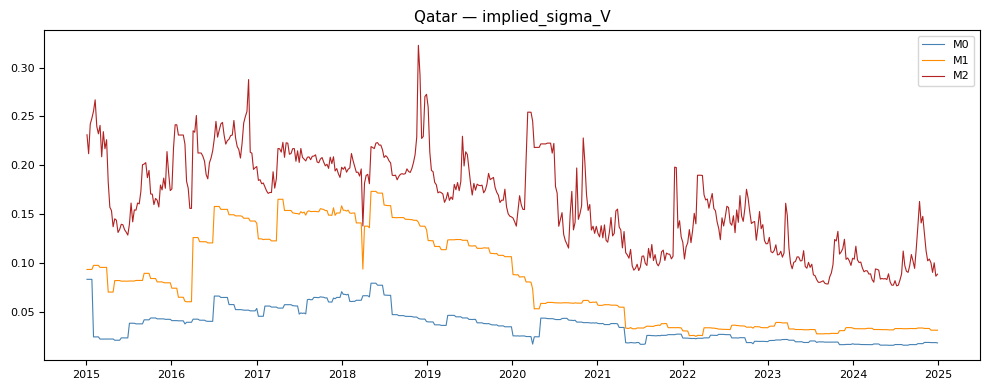

In [46]:
graphfunc('Qatar', 'implied_sigma_V', ['M0', 'M1', 'M2'])

In [47]:
t = HORIZON
sqt = np.sqrt(t)

# M0
V, sA, B, rf = panel['implied_V_M0'].values, panel['implied_sigma_V_M0'].values, panel['B_f'].values, panel['risk_free_rate'].values
panel['DD_M0'] = (np.log(V / B) + (rf - 0.5 * sA**2) * t) / (sA * sqt)

# M1: same formula, different V
V, sA = panel['implied_V_M1'].values, panel['implied_sigma_V_M1'].values
panel['DD_M1'] = (np.log(V / B) + (rf - 0.5 * sA**2) * t) / (sA * sqt)

# M2: sigma_total, drift includes jump compensation
V2, s2 = panel['implied_V_M2'].values, panel['implied_sigma_V_M2'].values
lam = panel['lambda_annual'].values
panel['DD_M2'] = (np.log(V2 / B) + (rf - 0.5 * s2**2) * t) / (s2 * sqt)

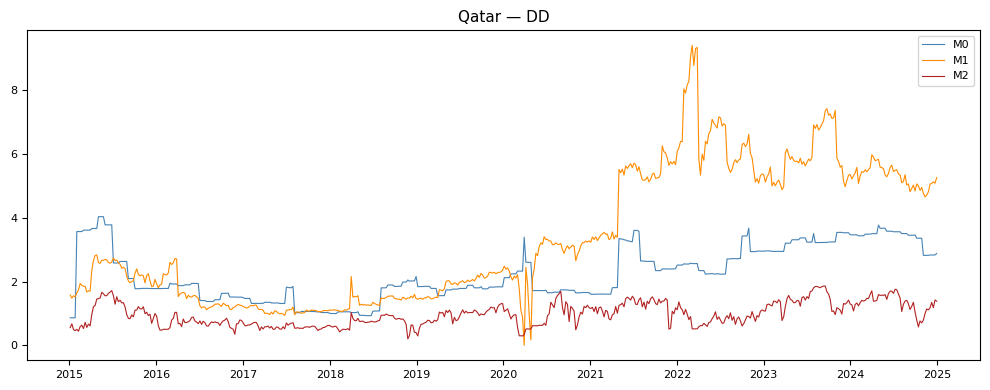

In [48]:
graphfunc('Qatar', 'DD', ['M0', 'M1', 'M2'])

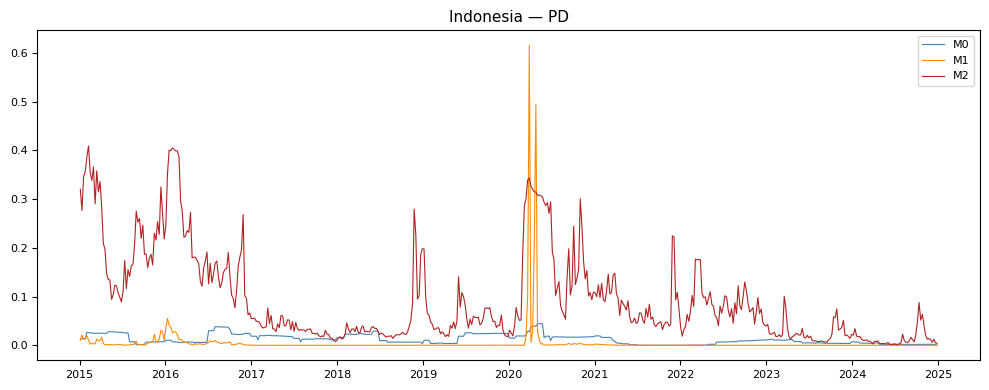

In [49]:
panel['PD_M0'] = norm.cdf(-panel['DD_M0'])
panel['PD_M1'] = norm.cdf(-panel['DD_M1'])
panel['PD_M2'] = norm.cdf(-panel['DD_M2'])

graphfunc('Indonesia', 'PD', ['M0', 'M1', 'M2'])




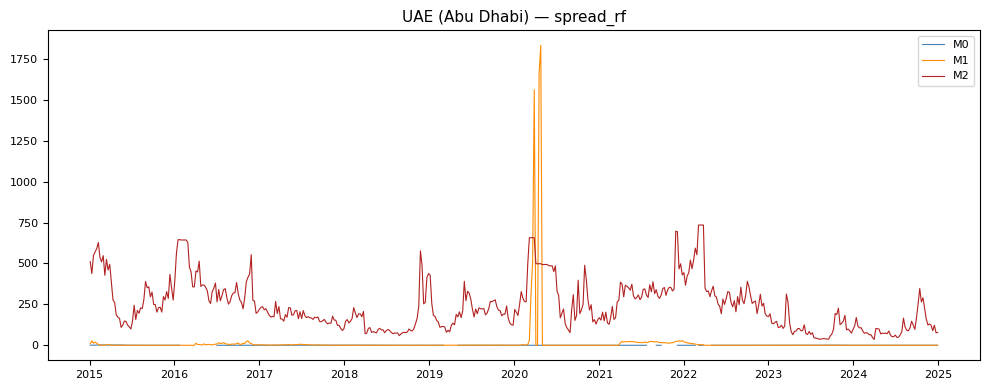

In [50]:
panel['spread_rf_M0'] =  -(1/t) * np.log(1 - (1 - RECOVERY) * panel['PD_M0']) * 10000
panel['spread_rf_M1'] =  -(1/t) * np.log(1 - (1 - RECOVERY) * panel['PD_M1']) * 10000
panel['spread_rf_M2'] =  -(1/t) * np.log(1 - (1 - RECOVERY) * panel['PD_M2']) * 10000

graphfunc('UAE (Abu Dhabi)', 'spread_rf', ['M0', 'M1', 'M2'])

In [51]:
V0, s0 = panel['implied_V_M0'].values, panel['implied_sigma_V_M0'].values
d1_M0 = (np.log(V0 / B) + (rf + 0.5 * s0**2) * t) / (s0 * sqt)
d2_M0 = d1_M0 - s0 * sqt
panel['put_M0'] = np.maximum(B * np.exp(-rf * t) * norm.cdf(-d2_M0) - V0 * norm.cdf(-d1_M0), 0)


V1, s1 = panel['implied_V_M1'].values, panel['implied_sigma_V_M1'].values
d1_M1 = (np.log(V1 / B) + (rf + 0.5 * s1**2) * t) / (s1 * sqt)
d2_M1 = d1_M1 - s1 * sqt
panel['put_M1'] = np.maximum(B * np.exp(-rf * t) * norm.cdf(-d2_M1) - V1 * norm.cdf(-d1_M1), 0)


def compute_put_M2(V, sA, B, rf, lam, J, gamma, t, n_terms=80):
    J_eff = gamma * J
    k = J_eff
    log1J = np.log(1 + J_eff)
    lam_prime = lam * (1 + k)
    lam_T = lam_prime * t
    sqt = np.sqrt(t)

    put = np.zeros(len(V))

    for i in range(len(V)):
        if np.isnan(V[i]) or np.isnan(sA[i]) or V[i] <= 0 or sA[i] <= 0:
            put[i] = np.nan
            continue

        mode = max(int(lam_T[i]), 0)
        n_low = max(0, mode - 40)
        n_high = mode + 40
        log_lam_T = np.log(lam_T[i] + 1e-300)

        p = 0.0
        for n in range(n_low, n_high + 1):
            log_w = -lam_T[i] + n * log_lam_T - gammaln(n + 1)
            w = np.exp(log_w)
            if w < 1e-15:
                continue

            r_n = rf[i] - lam[i] * k + n * log1J / t
            d1_n = (np.log(V[i] / B[i]) + (r_n + 0.5 * sA[i]**2) * t) / (sA[i] * sqt)
            d2_n = d1_n - sA[i] * sqt
            bs_put = B[i] * np.exp(-r_n * t) * norm.cdf(-d2_n) - V[i] * norm.cdf(-d1_n)
            p += w * max(bs_put, 0)

        put[i] = p

    return put

panel['put_M2'] = compute_put_M2(
    panel['implied_V_M2'].values, panel['implied_sigma_V_M2'].values,
    B, rf, panel['lambda_annual'].values, J, GAMMA, t
)


KeyboardInterrupt: 

KeyError: 'put_M2'

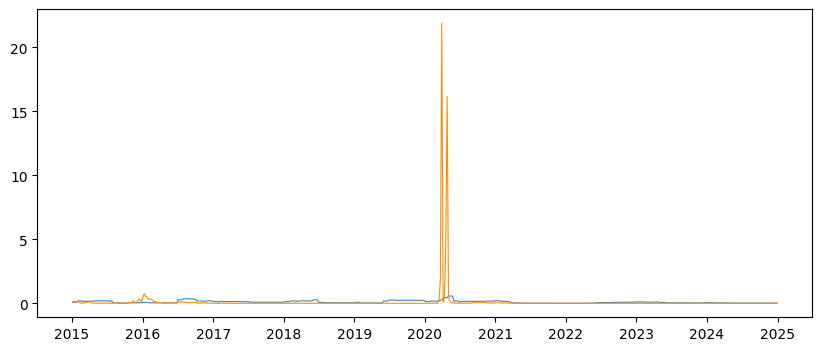

In [52]:

graphfunc('Indonesia', 'put', ['M0', 'M1', 'M2'])

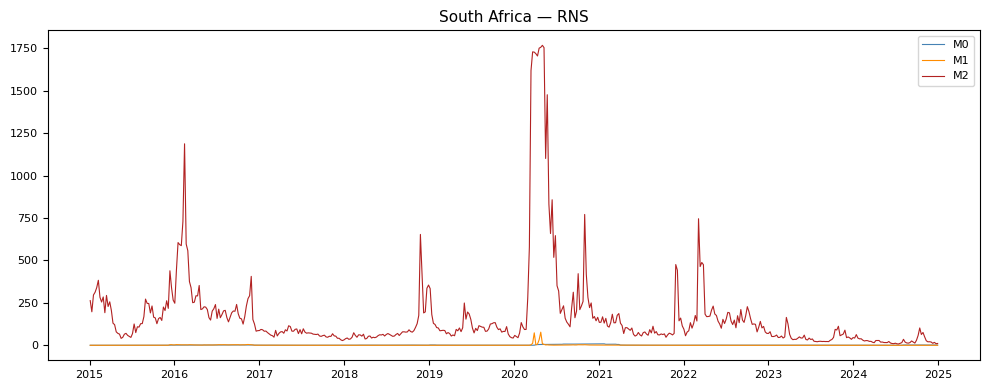

In [30]:
df_debt = B * np.exp(-rf * t)

panel['risky_debt_M0'] = df_debt - panel['put_M0']
panel['risky_debt_M1'] = df_debt - panel['put_M1']
panel['risky_debt_M2'] = df_debt - panel['put_M2']

t = HORIZON

# M0
V0 = panel['implied_V_M0'].values
s0 = panel['implied_sigma_V_M0'].values
B  = panel['B_f'].values
rf = panel['risk_free_rate'].values
sqt = np.sqrt(t)

d1_M0 = (np.log(V0 / B) + (rf + 0.5 * s0**2) * t) / (s0 * sqt)
d2_M0 = d1_M0 - s0 * sqt
panel['RNS_M0'] = -1/t * np.log(np.exp(rf * t) * (V0 / B) * (1 - norm.cdf(d1_M0)) + norm.cdf(d2_M0)) * 10000

# M1: same formula, different V
V1 = panel['implied_V_M1'].values
s1 = panel['implied_sigma_V_M1'].values

d1_M1 = (np.log(V1 / B) + (rf + 0.5 * s1**2) * t) / (s1 * sqt)
d2_M1 = d1_M1 - s1 * sqt
panel['RNS_M1'] = -1/t * np.log(np.exp(rf * t) * (V1 / B) * (1 - norm.cdf(d1_M1)) + norm.cdf(d2_M1)) * 10000

# M2: same closed-form, using sigma_total
V2 = panel['implied_V_M2'].values
s2 = panel['implied_sigma_V_M2'].values  # this is sigma_total

d1_M2 = (np.log(V2 / B) + (rf + 0.5 * s2**2) * t) / (s2 * sqt)
d2_M2 = d1_M2 - s2 * sqt
panel['RNS_M2'] = -1/t * np.log(np.exp(rf * t) * (V2 / B) * (1 - norm.cdf(d1_M2)) + norm.cdf(d2_M2)) * 10000


graphfunc('South Africa', 'RNS', ['M0', 'M1', 'M2'])

In [53]:
rf_bps = panel['risk_free_rate'].values * 10000

for m in ['M0', 'M1', 'M2']:
    # From reduced-form spread
    panel[f'yield_rf_{m}'] = panel[f'spread_rf_{m}'] + rf_bps

    # From structural RNS
    panel[f'yield_rns_{m}'] = panel[f'RNS_{m}'] + rf_bps

# Market yield
panel['yield_market'] = panel[CDS_COL] + rf_bps

graphfunc('Mexico', 'RNS', ['M0', 'M1', 'M2'])

KeyError: 'RNS_M0'

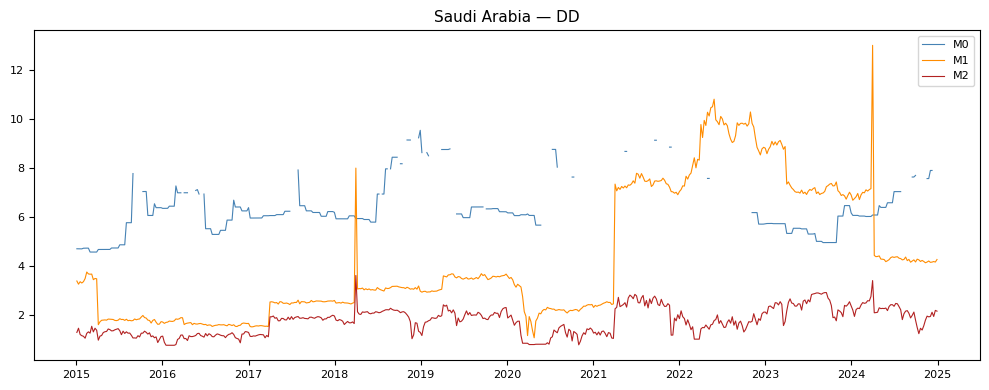

In [54]:
for m in ['M0', 'M1', 'M2']:
    panel[f'leverage_{m}'] = panel['B_f'] / panel[f'implied_V_{m}']

graphfunc('Saudi Arabia', 'DD', ['M0', 'M1', 'M2'])    

In [55]:
panel.to_csv('../output/results/final_inchallah/complete_results_weekly_15_dampening.csv', index=False)

In [34]:
def scatter(country, x_col, y_col, fit='none'):
    """
    fit: 'none', 'linear', 'quadratic', 'lowess'
    """
    d = panel[panel[COUNTRY_COL] == country].dropna(subset=[x_col, y_col])
    x, y = d[x_col].values, d[y_col].values

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, s=10, alpha=0.4, color='#2C5F8A', edgecolors='none')

    if fit == 'linear':
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, m * xs + b, 'r-', lw=1.5)
        r2 = np.corrcoef(x, y)[0, 1]**2
        ax.text(0.05, 0.95, f'β={m:.4f}\nR²={r2:.4f}', transform=ax.transAxes,
                fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

    elif fit == 'quadratic':
        c = np.polyfit(x, y, 2)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, np.polyval(c, xs), 'r-', lw=1.5)
        yhat = np.polyval(c, x)
        r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
        ax.text(0.05, 0.95, f'R²={r2:.4f}', transform=ax.transAxes,
                fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

    elif fit == 'lowess':
        from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
        fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
        ax.plot(fitted[:, 0], fitted[:, 1], 'r-', lw=2)

    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{country}: {y_col} vs {x_col}', fontsize=11)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

def scatter_all(x_col, y_col, fit='none', by_group=True):
    """
    Scatter plot pooling all countries.
    by_group: color exporters vs controls separately
    fit: 'none', 'linear', 'quadratic', 'lowess'
    """
    d = panel.dropna(subset=[x_col, y_col])

    fig, ax = plt.subplots(figsize=(8, 6))

    if by_group:
        for grp, color, label in [('Exporter', '#C0392B', 'Exporters'),
                                   ('Control', '#2C5F8A', 'Controls')]:
            g = d[d['group'] == grp]
            ax.scatter(g[x_col], g[y_col], s=6, alpha=0.25, color=color,
                       edgecolors='none', label=f'{label} (n={len(g)})')

            if fit == 'linear':
                x, y = g[x_col].values, g[y_col].values
                m, b = np.polyfit(x, y, 1)
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, m * xs + b, color=color, lw=2)
                r2 = np.corrcoef(x, y)[0, 1]**2
                ax.plot([], [], ' ', label=f'  R²={r2:.4f}  β={m:.4f}')

            elif fit == 'quadratic':
                x, y = g[x_col].values, g[y_col].values
                c = np.polyfit(x, y, 2)
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, np.polyval(c, xs), color=color, lw=2)
                yhat = np.polyval(c, x)
                r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
                ax.plot([], [], ' ', label=f'  R²={r2:.4f}')

            elif fit == 'lowess':
                from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
                x, y = g[x_col].values, g[y_col].values
                fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
                ax.plot(fitted[:, 0], fitted[:, 1], color=color, lw=2.5)
    else:
        x, y = d[x_col].values, d[y_col].values
        ax.scatter(x, y, s=6, alpha=0.25, color='#2C5F8A', edgecolors='none')

        if fit == 'linear':
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 200)
            ax.plot(xs, m * xs + b, 'r-', lw=2)
            r2 = np.corrcoef(x, y)[0, 1]**2
            ax.text(0.05, 0.95, f'β={m:.4f}\nR²={r2:.4f}', transform=ax.transAxes,
                    fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.8))

        elif fit == 'lowess':
            from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
            fitted = sm_lowess(y, x, frac=0.3, return_sorted=True)
            ax.plot(fitted[:, 0], fitted[:, 1], 'r-', lw=2.5)

    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)
    ax.set_title(f'{y_col} vs {x_col}', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

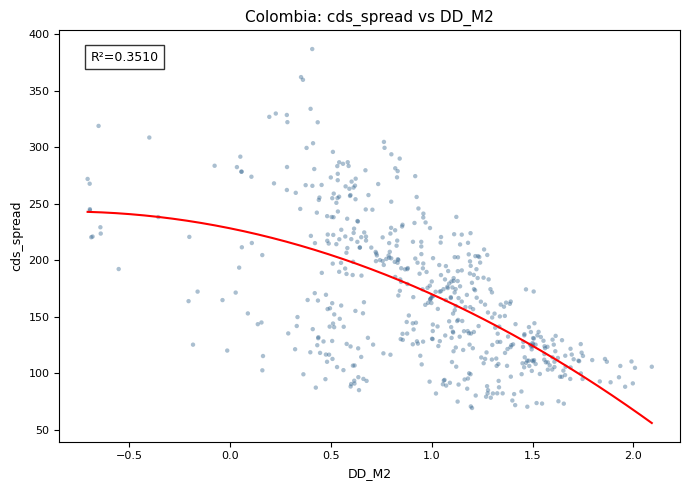

In [37]:
scatter('Colombia', 'DD_M2', 'cds_spread', 'quadratic')

In [522]:
def country_summary(col, models=['M0', 'M1', 'M2'], stat='mean'):
    """Print grouped summary of a variable across models.
    col: base name, e.g. 'DD', 'PD', 'spread_rf', 'implied_V', 'implied_sigma_V'
    stat: 'mean', 'median', 'std', 'min', 'max'
    """
    cols = [f'{col}_{m}' for m in models]
    available = [c for c in cols if c in panel.columns]
    
    agg = panel.groupby(COUNTRY_COL)[available].agg(stat)
    agg['exporter'] = agg.index.isin(EXPORTERS)
    agg = agg.sort_values('exporter', ascending=False)
    
    print(f"\n{stat.upper()} of {col} by country:")
    print(f"{'Country':<20} {'Exporter':>8}", end='')
    for c in available:
        print(f" {c:>18}", end='')
    print()
    print("-" * (30 + 19 * len(available)))
    
    for country, row in agg.iterrows():
        print(f"{country:<20} {'Yes' if row['exporter'] else 'No':>8}", end='')
        for c in available:
            print(f" {row[c]:>18.4f}", end='')
        print()
    
    # Group means
    print("-" * (30 + 19 * len(available)))
    for grp, label in [(True, 'Exporters'), (False, 'Controls')]:
        sub = agg[agg['exporter'] == grp]
        print(f"{label:<20} {'':>8}", end='')
        for c in available:
            print(f" {sub[c].mean():>18.4f}", end='')
        print()

# Usage:
country_summary('DD', stat='min')
# country_summary('PD', stat='median')
# country_summary('spread_rf')
# country_summary('implied_sigma_V', models=['M0', 'M2'])


MIN of DD by country:
Country              Exporter              DD_M0              DD_M1              DD_M2
---------------------------------------------------------------------------------------
Brazil                    Yes             1.4528             1.9733             2.1619
Colombia                  Yes             1.4187             0.1596             1.2248
Egypt                     Yes             0.1882             0.4439             0.4405
Malaysia                  Yes             2.6902            -1.1733             0.7677
Mexico                    Yes             1.8584             0.1327             1.1626
Qatar                     Yes             0.8632             1.2419             1.3643
Saudi Arabia              Yes             4.5561             5.4720             5.5242
UAE (Abu Dhabi)           Yes             2.9558            -1.8406             0.6626
Chile                      No             2.0248             1.6392             2.0261
China              